# **Calidad del servicio energético en Zonas No Interconectadas de Colombia: análisis de 52 municipios con monitoreo de telemetría IPSE 2020-2025**

## **1. CONFIGURACIÓN INICIAL**

### **1.1. Importación de librerias**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import unicodedata

### **1.2. Definición de rutas**

In [2]:
URL1 = "C:/Users/Lenovo/Desktop/ANALISIS ZNI/DATASETS/DIVIPOLA_-_Códigos_cabeceras_-_Centros_poblados_20260126.csv"
URL2 = "C:/Users/Lenovo/Desktop/ANALISIS ZNI/DATASETS/Estado_de_la_prestación_del_servicio_de_energía_en_Zonas_No_Interconectadas_20260122.csv"
URL3 = "C:/Users/Lenovo/Desktop/ANALISIS ZNI/DATASETS/Anexo_ICEE_2023_dpto_mpio.xlsx"


### **1.3. Funciones**

In [3]:
def eliminar_tildes(texto):
    return unicodedata.normalize('NFD', texto).encode('ascii', 'ignore').decode('utf-8')

## **2. CARGA DE DATOS**

In [4]:
df_localidades = pd.read_csv(URL1).drop(2) #se dropea 2 debido a que tiene doble coma.

In [5]:
df_ZNI = pd.read_csv(URL2,
                     decimal=',',
                     thousands= '.',
                     parse_dates=["FECHA DE DEMANDA MÁXIMA"],
                     date_format= "%Y %b %d %I:%M:%S %p")

In [6]:
df_ICEE_municipios = pd.read_excel(URL3, sheet_name='ICEE_MPIO')

## **3. LIMPIEZA**

### **3.1. DIVIPOLA**

In [7]:
df_localidades

,Código Departamento,Nombre_departamento,Codigo Municipio,Nombre Municipio,Código Centro Poblado,Nombre Centro Poblado,Tipo*,longitud,Latitud
0,17,CALDAS,17050,ARANZAZU,17050006,SAN RAFAEL,CP,"-75,523505","5,261945"
1,17,CALDAS,17050,ARANZAZU,17050012,LA HONDA,CP,"-75,512562","5,253714"
3,5,ANTIOQUIA,5001,MEDELLÍN,5001001,PALMITAS,CP,"-75,690573","6,343919"
4,5,ANTIOQUIA,5001,MEDELLÍN,5001004,SANTA ELENA,CP,"-75,501293","6,210599"
5,5,ANTIOQUIA,5001,MEDELLÍN,5001009,ALTAVISTA,CP,"-75,643706","6,221429"
...,...,...,...,...,...,...,...,...,...
8156,99,VICHADA,99773,CUMARIBO,99773028,GUACO BAJO,CP,"-70,16446","3,364312"
8157,99,VICHADA,99773,CUMARIBO,99773029,GUACO ALTO,CP,"-70,131371","3,401846"
8158,99,VICHADA,99773,CUMARIBO,99773030,CAÑO BOCÓN,CP,"-68,657583","3,965914"
8159,99,VICHADA,99773,CUMARIBO,99773031,CAMUNIANAE,CP,"-69,059251","4,366269"


In [8]:
df_localidades.info()

<class 'pandas.DataFrame'>
Index: 8160 entries, 0 to 8160
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Código Departamento    8160 non-null   int64
 1   Nombre_departamento    8160 non-null   str  
 2   Codigo Municipio       8160 non-null   int64
 3   Nombre Municipio       8160 non-null   str  
 4   Código Centro Poblado  8160 non-null   int64
 5   Nombre Centro Poblado  8160 non-null   str  
 6   Tipo*                  8160 non-null   str  
 7   longitud               8160 non-null   str  
 8   Latitud                8160 non-null   str  
dtypes: int64(3), str(6)
memory usage: 1.0 MB


In [9]:
df_localidades.isna().sum()

Código Departamento      0
Nombre_departamento      0
Codigo Municipio         0
Nombre Municipio         0
Código Centro Poblado    0
Nombre Centro Poblado    0
Tipo*                    0
longitud                 0
Latitud                  0
dtype: int64

In [10]:
df_localidades[['longitud', 'Latitud']] = df_localidades[['longitud', 'Latitud']].replace(",", ".", regex=True).astype(float)

In [11]:
df_localidades.columns = df_localidades.columns.str.upper()

In [12]:
df_localidades.rename(columns = {'TIPO*' : 'TIPO',
                                'CÓDIGO DEPARTAMENTO' : 'ID DEPARTAMENTO',
                                'NOMBRE_DEPARTAMENTO' : 'DEPARTAMENTO',
                                'CODIGO MUNICIPIO' : 'ID MUNICIPIO',
                                'NOMBRE MUNICIPIO' : 'MUNICIPIO',
                                'CÓDIGO CENTRO POBLADO' : 'ID LOCALIDAD',
                                'NOMBRE CENTRO POBLADO' : 'LOCALIDAD'}, 
                      inplace= True)

### **3.2. ZNI**

In [13]:
df_ZNI

,ID DEPATAMENTO,DEPARTAMENTO,ID MUNICIPIO,MUNICIPIO,ID LOCALIDAD,LOCALIDAD,AÑO SERVICIO,MES SERVICIO,ENERGÍA ACTIVA,ENERGÍA REACTIVA,POTENCIA MÁXIMA,DÍA DE DEMANDA MÁXIMA,FECHA DE DEMANDA MÁXIMA,PROMEDIO DIARIO EN HORAS
0,91,AMAZONAS,91001,LETICIA,91001000,LETICIA (LETICIA - AMAZONAS),2020,1,3930642,1251191,7768.76,lunes,2020-01-27 14:15:00,24.0000
1,91,AMAZONAS,91540,PUERTO NARIÑO,91540000,PUERTO NARIÑO (PUERTO NARIÑO - AMAZONAS),2020,1,103897,36304,227.04,miércoles,2020-01-22 19:15:00,24.0000
2,91,AMAZONAS,91798,TARAPACÁ (ANM),91798000,TARAPACÁ (TARAPACÁ (ANM) - AMAZONAS),2020,1,22864,9277,88.96,jueves,2020-01-30 19:30:00,10.1900
3,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,5873001,SAN ANTONIO DE PADUA (VIGÍA DEL FUERTE - ANTIO...,2020,1,5617,1381,53.66,jueves,2020-01-23 19:45:00,4.1300
4,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,5873002,VEGÁEZ (VIGÍA DEL FUERTE - ANTIOQUIA),2020,1,2217,539,39.07,miércoles,2020-01-29 19:45:00,3.1700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5983,97,VAUPÉS,97161,CARURÚ,97161000,CARURÚ(CARURÚ - VAUPÉS),2025,11,40640,7582,106.04,viernes,2025-11-07 18:45:00,17.0500
5984,97,VAUPÉS,97666,TARAIRA,97666000,TARAIRA(TARAIRA - VAUPÉS),2025,11,49902,12875,150.92,martes,2025-11-04 12:30:00,14.2833
5985,99,VICHADA,99001,PUERTO CARREÑO,99001000,PUERTO CARREÑO(PUERTO CARREÑO - VICHADA),2025,11,2817887,720573,5522.00,miércoles,2025-11-19 13:30:00,23.9500
5986,99,VICHADA,99001,PUERTO CARREÑO,99001002,CASUARITO(PUERTO CARREÑO - VICHADA),2025,11,14567,7108,85.05,viernes,2025-11-21 16:30:00,7.6250


In [43]:
prueba = df_ZNI[df_ZNI['ID LOCALIDAD'].astype(str).str.endswith('0')]
prueba['ID MUNICIPIO'].nunique()

33

In [15]:
df_ZNI.info()

<class 'pandas.DataFrame'>
RangeIndex: 5988 entries, 0 to 5987
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID DEPATAMENTO            5988 non-null   int64         
 1   DEPARTAMENTO              5988 non-null   str           
 2   ID MUNICIPIO              5988 non-null   int64         
 3   MUNICIPIO                 5988 non-null   str           
 4   ID LOCALIDAD              5988 non-null   int64         
 5   LOCALIDAD                 5988 non-null   str           
 6   AÑO SERVICIO              5988 non-null   int64         
 7   MES SERVICIO              5988 non-null   int64         
 8   ENERGÍA ACTIVA            5988 non-null   int64         
 9   ENERGÍA REACTIVA          5988 non-null   int64         
 10  POTENCIA MÁXIMA           5908 non-null   float64       
 11  DÍA DE DEMANDA MÁXIMA     5907 non-null   str           
 12  FECHA DE DEMANDA MÁXIMA   5908 

In [16]:
df_ZNI.isna().sum()

ID DEPATAMENTO               0
DEPARTAMENTO                 0
ID MUNICIPIO                 0
MUNICIPIO                    0
ID LOCALIDAD                 0
LOCALIDAD                    0
AÑO SERVICIO                 0
MES SERVICIO                 0
ENERGÍA ACTIVA               0
ENERGÍA REACTIVA             0
POTENCIA MÁXIMA             80
DÍA DE DEMANDA MÁXIMA       81
FECHA DE DEMANDA MÁXIMA     80
PROMEDIO DIARIO EN HORAS     0
dtype: int64

In [17]:
df_ZNI.dropna(inplace = True)

In [18]:
df_ZNI['DÍA DE DEMANDA MÁXIMA'] = df_ZNI['DÍA DE DEMANDA MÁXIMA'].str.upper().apply(eliminar_tildes)

#lista de elementos unicos para verificar la que solo queda un valor por cada día
list(df_ZNI['DÍA DE DEMANDA MÁXIMA'].unique())

['LUNES', 'MIERCOLES', 'JUEVES', 'VIERNES', 'SABADO', 'MARTES', 'DOMINGO']

In [19]:
#Se corrige nombre de la columna departamentos en dataframe de ZNI
df_ZNI.rename(columns = {'ID DEPATAMENTO' : 'ID DEPARTAMENTO'}, inplace = True)

In [20]:
#Se dropean las filas que tengan un valor mayor a 24h en promedio diario de horas de servicio.
df_ZNI.drop(df_ZNI[df_ZNI['PROMEDIO DIARIO EN HORAS'] > 24].index, inplace = True)

In [21]:
filtro = df_ZNI.groupby('ID MUNICIPIO')['AÑO SERVICIO'].transform(lambda x: x.nunique() >= 2)
df_ZNI = df_ZNI[filtro]
df_ZNI

,ID DEPARTAMENTO,DEPARTAMENTO,ID MUNICIPIO,MUNICIPIO,ID LOCALIDAD,LOCALIDAD,AÑO SERVICIO,MES SERVICIO,ENERGÍA ACTIVA,ENERGÍA REACTIVA,POTENCIA MÁXIMA,DÍA DE DEMANDA MÁXIMA,FECHA DE DEMANDA MÁXIMA,PROMEDIO DIARIO EN HORAS
0,91,AMAZONAS,91001,LETICIA,91001000,LETICIA (LETICIA - AMAZONAS),2020,1,3930642,1251191,7768.76,LUNES,2020-01-27 14:15:00,24.0000
1,91,AMAZONAS,91540,PUERTO NARIÑO,91540000,PUERTO NARIÑO (PUERTO NARIÑO - AMAZONAS),2020,1,103897,36304,227.04,MIERCOLES,2020-01-22 19:15:00,24.0000
2,91,AMAZONAS,91798,TARAPACÁ (ANM),91798000,TARAPACÁ (TARAPACÁ (ANM) - AMAZONAS),2020,1,22864,9277,88.96,JUEVES,2020-01-30 19:30:00,10.1900
3,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,5873001,SAN ANTONIO DE PADUA (VIGÍA DEL FUERTE - ANTIO...,2020,1,5617,1381,53.66,JUEVES,2020-01-23 19:45:00,4.1300
4,5,ANTIOQUIA,5873,VIGÍA DEL FUERTE,5873002,VEGÁEZ (VIGÍA DEL FUERTE - ANTIOQUIA),2020,1,2217,539,39.07,MIERCOLES,2020-01-29 19:45:00,3.1700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5983,97,VAUPÉS,97161,CARURÚ,97161000,CARURÚ(CARURÚ - VAUPÉS),2025,11,40640,7582,106.04,VIERNES,2025-11-07 18:45:00,17.0500
5984,97,VAUPÉS,97666,TARAIRA,97666000,TARAIRA(TARAIRA - VAUPÉS),2025,11,49902,12875,150.92,MARTES,2025-11-04 12:30:00,14.2833
5985,99,VICHADA,99001,PUERTO CARREÑO,99001000,PUERTO CARREÑO(PUERTO CARREÑO - VICHADA),2025,11,2817887,720573,5522.00,MIERCOLES,2025-11-19 13:30:00,23.9500
5986,99,VICHADA,99001,PUERTO CARREÑO,99001002,CASUARITO(PUERTO CARREÑO - VICHADA),2025,11,14567,7108,85.05,VIERNES,2025-11-21 16:30:00,7.6250


### **3.3 ICEE MUNICIPAL**

In [22]:
df_ICEE_municipios

,Cod. DANE,Vigencia,Departamento,Municipio,VCS Urbano,VCS Rural,VCS Total,VT Urbano,VT Rural,VT,ICEE Urbano,ICEE Rural,ICEE Total,VSS Urbano,VSS Rural,VSS Total,Excedentes Total
0,5001,2023,Antioquia,Medellín,1002117,20700,1022817,1002117,20700,1022817,1.000000,1.000000,1.000000,0,0,0,25852
1,5002,2023,Antioquia,Abejorral,3977,4870,8847,4311,5984,10295,0.922524,0.813837,0.859349,334,1114,1448,Sin excedentes
2,5004,2023,Antioquia,Abriaquí,416,671,1087,567,782,1349,0.733686,0.858056,0.805782,151,111,262,Sin excedentes
3,5021,2023,Antioquia,Alejandría,1237,1096,2333,1533,1277,2810,0.806915,0.858262,0.830249,296,181,477,Sin excedentes
4,5030,2023,Antioquia,Amagá,6441,6195,12636,6633,7047,13680,0.971054,0.879097,0.923684,192,852,1044,Sin excedentes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1117,97889,2023,Vaupés,Yavaraté,0,0,0,0,186,186,0.000000,0.000000,0.000000,0,186,186,Sin excedentes
1118,99001,2023,Vichada,Puerto Carreño,5903,1695,7598,5903,1958,7861,1.000000,0.865679,0.966544,0,263,263,Sin excedentes
1119,99524,2023,Vichada,La Primavera,2371,1433,3804,2371,1433,3804,1.000000,1.000000,1.000000,0,0,0,502
1120,99624,2023,Vichada,Santa Rosalía,897,73,970,897,532,1429,1.000000,0.137218,0.678796,0,459,459,Sin excedentes


In [23]:
df_ICEE_municipios.isna().sum()

Cod. DANE           0
Vigencia            0
Departamento        0
Municipio           0
VCS Urbano          0
VCS Rural           0
VCS Total           0
VT Urbano           0
VT Rural            0
VT                  0
ICEE Urbano         0
ICEE Rural          0
ICEE Total          0
VSS Urbano          0
VSS Rural           0
VSS Total           0
Excedentes Total    0
dtype: int64

In [24]:
df_ICEE_municipios.columns = df_ICEE_municipios.columns.str.upper()

In [25]:
df_ICEE_municipios.rename(columns = {'COD. DANE' : 'ID MUNICIPIO'}, 
                          inplace = True)

In [26]:
#Se dropea columna vigencia ya que todos los datos son del 2023
df_ICEE_municipios.drop(columns = 'VIGENCIA', 
                        inplace = True)

In [27]:
df_ICEE_municipios.info()

<class 'pandas.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID MUNICIPIO      1122 non-null   int64  
 1   DEPARTAMENTO      1122 non-null   str    
 2   MUNICIPIO         1122 non-null   str    
 3   VCS URBANO        1122 non-null   int64  
 4   VCS RURAL         1122 non-null   int64  
 5   VCS TOTAL         1122 non-null   int64  
 6   VT URBANO         1122 non-null   int64  
 7   VT RURAL          1122 non-null   int64  
 8   VT                1122 non-null   int64  
 9   ICEE URBANO       1122 non-null   float64
 10  ICEE RURAL        1122 non-null   float64
 11  ICEE TOTAL        1122 non-null   float64
 12  VSS URBANO        1122 non-null   int64  
 13  VSS RURAL         1122 non-null   int64  
 14  VSS TOTAL         1122 non-null   int64  
 15  EXCEDENTES TOTAL  1122 non-null   object 
dtypes: float64(3), int64(10), object(1), str(2)
memory us

## **4. INTEGRACIÓN**

### **4.1. Combinación ZNI-DIVIPOLA**

In [28]:
df_municipios = df_localidades.groupby(['ID DEPARTAMENTO', 'ID MUNICIPIO'], as_index=False).first()[
    ['ID DEPARTAMENTO', 'ID MUNICIPIO', 'DEPARTAMENTO', 'MUNICIPIO', 'LONGITUD', 'LATITUD']]

In [29]:
df_ZNI_limpio = pd.merge(df_ZNI,
                          df_municipios,
                          how= 'left',
                          on= ['ID DEPARTAMENTO', 'ID MUNICIPIO'],
                          validate='many_to_one')

In [30]:
df_ZNI_limpio.drop(columns = ['DEPARTAMENTO_x', 'MUNICIPIO_x'], inplace = True)

DEPARTAMENTOS = df_ZNI_limpio.pop("DEPARTAMENTO_y")
MUNICIPIOS = df_ZNI_limpio.pop("MUNICIPIO_y")

df_ZNI_limpio.insert(1, 'DEPARTAMENTO', DEPARTAMENTOS) 
df_ZNI_limpio.insert(3, 'MUNICIPIO', MUNICIPIOS)


In [31]:
df_ZNI_limpio['LOCALIDAD'] = df_ZNI_limpio['LOCALIDAD'].str.split("(").str[0].str.strip()

df_ZNI_limpio['LOCALIDAD'] = df_ZNI_limpio['LOCALIDAD'].apply(eliminar_tildes)

### **4.2. Filtrar ICEEE**

In [32]:
municipios_a_filtrar = df_ZNI_limpio['ID MUNICIPIO']

df_ICEE_municipios_filtrado = df_ICEE_municipios[df_ICEE_municipios['ID MUNICIPIO'].isin(municipios_a_filtrar)].reset_index(drop = True)
df_ICEE_municipios_filtrado

,ID MUNICIPIO,DEPARTAMENTO,MUNICIPIO,VCS URBANO,VCS RURAL,VCS TOTAL,VT URBANO,VT RURAL,VT,ICEE URBANO,ICEE RURAL,ICEE TOTAL,VSS URBANO,VSS RURAL,VSS TOTAL,EXCEDENTES TOTAL
0,5873,Antioquia,Vigía Del Fuerte,682,1880,2562,1450,1880,3330,0.470345,1.000000,0.769369,768,0,768,Sin excedentes
1,13001,Bolívar,Cartagena De Indias,314150,20635,334785,314150,40598,354748,1.000000,0.508276,0.943726,0,19963,19963,Sin excedentes
2,18150,Caquetá,Cartagena Del Chairá,1,1150,1151,6817,5196,12013,0.000147,0.221324,0.095813,6816,4046,10862,Sin excedentes
3,18753,Caquetá,San Vicente Del Caguán,9556,7538,17094,9996,7621,17617,0.955982,0.989109,0.970313,440,83,523,Sin excedentes
4,19318,Cauca,Guapi,4525,3584,8109,4525,4271,8796,1.000000,0.839148,0.921896,0,687,687,Sin excedentes
5,19418,Cauca,López De Micay,805,5748,6553,805,5748,6553,1.000000,1.000000,1.000000,0,0,0,2429
6,19809,Cauca,Timbiquí,1907,7541,9448,1907,7652,9559,1.000000,0.985494,0.988388,0,111,111,Sin excedentes
7,27001,Chocó,Quibdó,42720,7384,50104,42720,7384,50104,1.000000,1.000000,1.000000,0,0,0,9288
8,27006,Chocó,Acandí,2432,3959,6391,2432,3959,6391,1.000000,1.000000,1.000000,0,0,0,2500
9,27025,Chocó,Alto Baudó,782,4399,5181,1113,6440,7553,0.702606,0.683075,0.685953,331,2041,2372,Sin excedentes


In [44]:
df_municipios_ICEE = df_localidades.groupby(['ID DEPARTAMENTO', 'ID MUNICIPIO'], as_index=False).first()[
    ['ID DEPARTAMENTO', 'DEPARTAMENTO', 'MUNICIPIO', 'ID MUNICIPIO']]

df_ICEE_final = pd.merge(df_ICEE_municipios_filtrado,
                          df_municipios_ICEE,
                          how= 'left',
                          on= 'ID MUNICIPIO',
                          validate='many_to_one')

df_ICEE_final.drop(columns = ['DEPARTAMENTO_x', 'MUNICIPIO_x'], inplace = True)

POP_ID_DEPARTAMENTOS= df_ICEE_final.pop("ID DEPARTAMENTO")
POP_DEPARTAMENTOS = df_ICEE_final.pop("DEPARTAMENTO_y")
POP_MUNICIPIOS = df_ICEE_final.pop("MUNICIPIO_y")
POP_ID_MUNICIPIOS= df_ICEE_final.pop("ID MUNICIPIO")

df_ICEE_final.insert(0 , 'ID DEPARTAMENTO', POP_ID_DEPARTAMENTOS) 
df_ICEE_final.insert(1, 'DEPARTAMENTO', POP_DEPARTAMENTOS) 
df_ICEE_final.insert(2, 'ID MUNICIPIO', POP_ID_MUNICIPIOS)
df_ICEE_final.insert(3, 'MUNICIPIO', POP_MUNICIPIOS)

## **5. ANÁLISIS EXPLORATORIO**

In [52]:
df_promedio_horas_servicio = pd.DataFrame(df_ZNI_limpio.groupby(df_ZNI_limpio['FECHA DE DEMANDA MÁXIMA'].dt.strftime('%Y'))['PROMEDIO DIARIO EN HORAS'].mean())
df_promedio_horas_servicio

,PROMEDIO DIARIO EN HORAS
FECHA DE DEMANDA MÁXIMA,
2020,11.390470
2021,12.149257
2022,12.799361
2023,11.683868
2024,11.634686
2025,11.181640


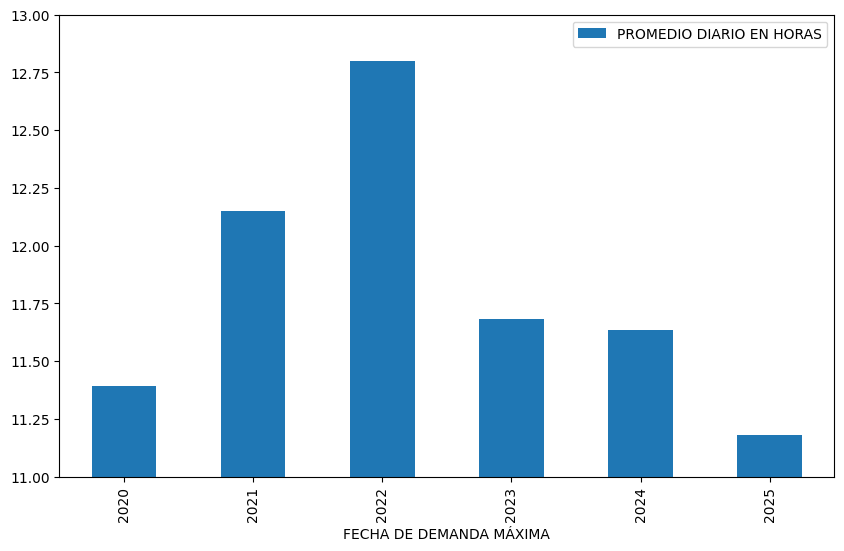

In [55]:
df_promedio_horas_servicio.plot(kind = 'bar', figsize = (10, 6), ylim=(11, 13));

In [48]:
df_ZNI_limpio['MUNICIPIO'].value_counts()

MUNICIPIO
TIMBIQUÍ                   388
BUENAVENTURA               342
BAJO BAUDÓ                 287
LA TOLA                    276
LÓPEZ DE MICAY             262
NUQUÍ                      249
EL CHARCO                  228
BOJAYÁ                     226
UNGUÍA                     203
SAN ANDRÉS DE TUMACO       203
BAHÍA SOLANO               185
CARTAGENA DE INDIAS        171
SAN VICENTE DEL CAGUÁN     159
VIGÍA DEL FUERTE           143
ACANDÍ                     138
GUAPI                      119
SANTA BÁRBARA              118
ALTO BAUDÓ                 114
PUERTO CARREÑO             112
JURADÓ                     112
PUERTO LEGUÍZAMO           111
MEDIO ATRATO               108
INÍRIDA                    105
CARTAGENA DEL CHAIRÁ       103
EL LITORAL DEL SAN JUAN    102
BARRANCOMINAS               74
OLAYA HERRERA               74
CIÉNAGA                     70
MITÚ                        70
LETICIA                     69
URIBIA                      68
MAPIRIPÁN                   6

In [49]:
df_ZNI_limpio['MUNICIPIO'].nunique()

52

In [50]:
df_ZNI_limpio['DEPARTAMENTO'].unique()

<ArrowStringArray>
[                                                'AMAZONAS',
                                                'ANTIOQUIA',
 'ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA',
                                                  'BOLÍVAR',
                                                  'CAQUETÁ',
                                                 'CASANARE',
                                                    'CAUCA',
                                                    'CHOCÓ',
                                                  'GUAINÍA',
                                                 'GUAVIARE',
                                               'LA GUAJIRA',
                                                'MAGDALENA',
                                                     'META',
                                                   'NARIÑO',
                                                 'PUTUMAYO',
                                          'VALLE DEL CAUCA',
     

In [51]:
df_ZNI_limpio.isna().sum()

ID DEPARTAMENTO             0
DEPARTAMENTO                1
ID MUNICIPIO                0
MUNICIPIO                   1
ID LOCALIDAD                0
LOCALIDAD                   0
AÑO SERVICIO                0
MES SERVICIO                0
ENERGÍA ACTIVA              0
ENERGÍA REACTIVA            0
POTENCIA MÁXIMA             0
DÍA DE DEMANDA MÁXIMA       0
FECHA DE DEMANDA MÁXIMA     0
PROMEDIO DIARIO EN HORAS    0
LONGITUD                    1
LATITUD                     1
dtype: int64

## **6. EXPORTACIÓN**